# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Aldo Maretra Putra
- **Email:** aldomaretraputra7@gmail.com
- **ID Dicoding:** aldomp7

## Menentukan Pertanyaan Bisnis

Analisis ini menggunakan pendekatan **SMART Question** agar pertanyaan bisnis bersifat spesifik, terukur, relevan, dan memiliki batas waktu sesuai periode data.

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan **total revenue** dan **jumlah pesanan delivered** tertinggi pada E-Commerce Public Dataset selama periode 2016–2018, sehingga perusahaan dapat menentukan prioritas promosi dan pengelolaan stok?
- **Pertanyaan 2:** Bagaimana perbedaan **skor ulasan pelanggan** berdasarkan **durasi pengiriman** dan **status keterlambatan terhadap estimasi** pada pesanan delivered selama periode 2016–2018, sehingga perusahaan dapat menentukan prioritas perbaikan layanan logistik?

Selain dua pertanyaan utama tersebut, analisis lanjutan dilakukan menggunakan **RFM Analysis** untuk mengelompokkan pelanggan berdasarkan **Recency**, **Frequency**, dan **Monetary** tanpa menggunakan algoritma machine learning.

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Data Wrangling

Tahap ini meliputi proses **gathering data**, **assessing data**, dan **cleaning data** agar dataset siap digunakan untuk EDA, visualisasi, analisis lanjutan, dan dashboard Streamlit.

### Gathering Data

Pada tahap ini seluruh file CSV dari **E-Commerce Public Dataset** dimuat ke dalam dataframe. Dataset terdiri dari 9 file CSV yang saling terhubung melalui beberapa key seperti `order_id`, `customer_id`, `customer_unique_id`, `product_id`, dan `seller_id`.

In [2]:
DATA_DIR = Path("data")

customers_df = pd.read_csv(DATA_DIR / "customers_dataset.csv")
geolocation_df = pd.read_csv(DATA_DIR / "geolocation_dataset.csv")
order_items_df = pd.read_csv(DATA_DIR / "order_items_dataset.csv")
order_payments_df = pd.read_csv(DATA_DIR / "order_payments_dataset.csv")
order_reviews_df = pd.read_csv(DATA_DIR / "order_reviews_dataset.csv")
orders_df = pd.read_csv(DATA_DIR / "orders_dataset.csv")
products_df = pd.read_csv(DATA_DIR / "products_dataset.csv")
sellers_df = pd.read_csv(DATA_DIR / "sellers_dataset.csv")
category_translation_df = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

all_data = {
    "customers": customers_df,
    "geolocation": geolocation_df,
    "order_items": order_items_df,
    "order_payments": order_payments_df,
    "order_reviews": order_reviews_df,
    "orders": orders_df,
    "products": products_df,
    "sellers": sellers_df,
    "category_translation": category_translation_df,
}

profile_df = pd.DataFrame({
    "dataset": list(all_data.keys()),
    "rows": [df.shape[0] for df in all_data.values()],
    "columns": [df.shape[1] for df in all_data.values()]
})

profile_df

,dataset,rows,columns
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,products,32951,9
7,sellers,3095,4
8,category_translation,71,2


**Insight:**

- Seluruh 9 file CSV berhasil dimuat, termasuk `geolocation_dataset.csv`.
- Analisis utama difokuskan pada data pesanan, item pesanan, pelanggan, produk, pembayaran, dan ulasan karena kolom tersebut paling relevan untuk menjawab pertanyaan bisnis.
- Dataset geolocation tetap dimuat dan dinilai kualitasnya, tetapi tidak digabungkan ke dataset utama karena pertanyaan bisnis tidak membutuhkan koordinat lokasi.

### Assessing Data

Pada tahap ini dilakukan pemeriksaan tipe data, missing values, duplikasi, dan status pesanan. Tujuannya adalah menentukan masalah kualitas data yang perlu ditangani sebelum analisis.

In [3]:
def data_quality_summary(df, dataset_name):
    return pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_value": df.isna().sum().values,
        "missing_percentage": (df.isna().mean() * 100).round(2).values,
        "duplicated_rows_in_dataset": df.duplicated().sum()
    })

quality_report = pd.concat(
    [data_quality_summary(df, name) for name, df in all_data.items()],
    ignore_index=True
)

quality_report[quality_report["missing_value"] > 0].sort_values(
    by=["dataset", "missing_percentage"], ascending=[True, False]
).reset_index(drop=True)

,dataset,column,dtype,missing_value,missing_percentage,duplicated_rows_in_dataset
0,order_reviews,review_comment_title,object,87656,88.34,0
1,order_reviews,review_comment_message,object,58247,58.70,0
2,orders,order_delivered_customer_date,object,2965,2.98,0
3,orders,order_delivered_carrier_date,object,1783,1.79,0
4,orders,order_approved_at,object,160,0.16,0
5,products,product_category_name,object,610,1.85,0
6,products,product_name_lenght,float64,610,1.85,0
7,products,product_description_lenght,float64,610,1.85,0
8,products,product_photos_qty,float64,610,1.85,0
9,products,product_weight_g,float64,2,0.01,0


In [4]:
duplicate_report = pd.DataFrame({
    "dataset": list(all_data.keys()),
    "duplicated_rows": [df.duplicated().sum() for df in all_data.values()]
})

duplicate_report

,dataset,duplicated_rows
0,customers,0
1,geolocation,261831
2,order_items,0
3,order_payments,0
4,order_reviews,0
5,orders,0
6,products,0
7,sellers,0
8,category_translation,0


In [5]:
orders_df["order_status"].value_counts().rename_axis("order_status").reset_index(name="count")

,order_status,count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [6]:
orders_df[[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Steps to Take:**

- Mengubah kolom tanggal pada `orders_df`, `order_items_df`, dan `order_reviews_df` menjadi tipe `datetime`.
- Menggabungkan tabel produk dengan tabel terjemahan kategori agar nama kategori lebih mudah dibaca.
- Mengagregasi review dan pembayaran pada level `order_id` karena satu order dapat memiliki lebih dari satu baris review atau pembayaran.
- Menggunakan order berstatus `delivered` untuk analisis revenue, durasi pengiriman, review, dan RFM agar metrik berasal dari transaksi yang selesai.
- Missing value pada komentar review tidak dihapus karena komentar teks tidak digunakan untuk menjawab pertanyaan bisnis.
- Missing value kategori produk diisi dengan label `unknown` agar produk tersebut tetap masuk dalam analisis.
- Duplikasi pada `geolocation_dataset.csv` tidak memengaruhi hasil karena dataset tersebut tidak digunakan dalam main analytical table.

**Insight:**

- Missing value pada tanggal pengiriman terutama muncul pada order yang belum terkirim, dibatalkan, atau unavailable sehingga tidak cocok digunakan untuk analisis durasi pengiriman.
- Kolom komentar review memiliki banyak missing value, tetapi hal tersebut tidak mengganggu analisis karena variabel review yang digunakan adalah `review_score`.

### Cleaning Data

Tahap cleaning dilakukan dengan memperbaiki tipe data, menggabungkan dataset penting, membuat fitur turunan, dan menyiapkan dataset bersih untuk analisis.

In [7]:
# Mengubah kolom tanggal menjadi datetime
order_datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"], errors="coerce")
order_reviews_df["review_creation_date"] = pd.to_datetime(order_reviews_df["review_creation_date"], errors="coerce")
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"], errors="coerce")

# Menggabungkan produk dengan terjemahan nama kategori
products_clean_df = products_df.merge(
    category_translation_df,
    on="product_category_name",
    how="left"
)

products_clean_df["product_category_name_english"] = products_clean_df[
    "product_category_name_english"
].fillna(products_clean_df["product_category_name"].fillna("unknown"))

# Agregasi review pada level order
reviews_agg_df = order_reviews_df.groupby("order_id", as_index=False).agg(
    review_score=("review_score", "mean"),
    review_count=("review_id", "nunique")
)

# Agregasi pembayaran pada level order
payments_sum_df = order_payments_df.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum")
)

payments_type_df = (
    order_payments_df.sort_values(["order_id", "payment_value"], ascending=[True, False])
    .drop_duplicates("order_id")[["order_id", "payment_type"]]
)

payments_agg_df = payments_sum_df.merge(payments_type_df, on="order_id", how="left")

In [8]:
# Membuat main dataframe pada level order item
main_df = (
    order_items_df
    .merge(orders_df, on="order_id", how="left")
    .merge(customers_df, on="customer_id", how="left")
    .merge(products_clean_df[["product_id", "product_category_name_english"]], on="product_id", how="left")
    .merge(reviews_agg_df, on="order_id", how="left")
    .merge(payments_agg_df, on="order_id", how="left")
)

main_df["product_category_name_english"] = main_df["product_category_name_english"].fillna("unknown")
main_df["revenue"] = main_df["price"] + main_df["freight_value"]
main_df["delivery_time_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400
main_df["estimated_delivery_days"] = (
    main_df["order_estimated_delivery_date"] - main_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400
main_df["delay_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400
main_df["is_late"] = np.where(main_df["delay_days"] > 0, "Late", "On-time/Early")
main_df["purchase_month"] = main_df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
main_df["purchase_year"] = main_df["order_purchase_timestamp"].dt.year

main_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,review_score,review_count,payment_value,payment_type,revenue,delivery_time_days,estimated_delivery_days,delay_days,is_late,purchase_month,purchase_year
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,5.00,1.00,72.19,credit_card,72.19,7.61,15.63,-8.01,On-time/Early,2017-09-01,2017
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,4.00,1.00,259.83,credit_card,259.83,16.22,18.55,-2.33,On-time/Early,2017-04-01,2017
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,furniture_decor,5.00,1.00,216.87,credit_card,216.87,7.95,21.39,-13.44,On-time/Early,2018-01-01,2018
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumery,4.00,1.00,25.78,credit_card,25.78,6.15,11.58,-5.44,On-time/Early,2018-08-01,2018
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,garden_tools,5.00,1.00,218.04,credit_card,218.04,25.11,40.42,-15.30,On-time/Early,2017-02-01,2017


In [9]:
# Dataset analisis hanya menggunakan order delivered agar revenue dan durasi pengiriman merepresentasikan transaksi selesai.
analysis_df = main_df[main_df["order_status"] == "delivered"].copy()

# Menghapus baris tanpa nilai review atau durasi pengiriman untuk analisis review dan delivery.
analysis_df = analysis_df.dropna(subset=["review_score", "delivery_time_days", "delay_days"])

analysis_df["delivery_group"] = pd.cut(
    analysis_df["delivery_time_days"],
    bins=[-1, 7, 14, 30, np.inf],
    labels=["<=7 days", "8-14 days", "15-30 days", ">30 days"]
)

order_level_df = analysis_df.drop_duplicates("order_id").copy()

cleaning_check = pd.DataFrame({
    "metric": [
        "main_df rows",
        "analysis_df rows",
        "unique delivered orders",
        "unique delivered customers",
        "missing review_score in analysis_df",
        "missing delivery_time_days in analysis_df"
    ],
    "value": [
        len(main_df),
        len(analysis_df),
        analysis_df["order_id"].nunique(),
        analysis_df["customer_unique_id"].nunique(),
        analysis_df["review_score"].isna().sum(),
        analysis_df["delivery_time_days"].isna().sum()
    ]
})

cleaning_check

,metric,value
0,main_df rows,112650
1,analysis_df rows,109362
2,unique delivered orders,95824
3,unique delivered customers,92747
4,missing review_score in analysis_df,0
5,missing delivery_time_days in analysis_df,0


**Insight:**

- Dataset bersih `analysis_df` berisi transaksi `delivered` yang memiliki informasi review dan durasi pengiriman.
- Fitur turunan yang dibuat meliputi `revenue`, `delivery_time_days`, `estimated_delivery_days`, `delay_days`, `is_late`, `purchase_month`, dan `delivery_group`.
- `order_level_df` dibuat untuk analisis yang harus berada pada level order agar satu order tidak dihitung berulang karena memiliki lebih dari satu item.

## Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami pola dasar data sebelum membuat visualisasi akhir dan kesimpulan bisnis.

In [10]:
summary_metrics = pd.DataFrame({
    "metric": [
        "Periode awal transaksi",
        "Periode akhir transaksi",
        "Total order delivered",
        "Total customer unik",
        "Total revenue",
        "Rata-rata review score",
        "Rata-rata durasi pengiriman (hari)"
    ],
    "value": [
        analysis_df["order_purchase_timestamp"].min(),
        analysis_df["order_purchase_timestamp"].max(),
        analysis_df["order_id"].nunique(),
        analysis_df["customer_unique_id"].nunique(),
        round(analysis_df["revenue"].sum(), 2),
        round(order_level_df["review_score"].mean(), 2),
        round(order_level_df["delivery_time_days"].mean(), 2)
    ]
})

summary_metrics

,metric,value
0,Periode awal transaksi,2016-09-15 12:16:38
1,Periode akhir transaksi,2018-08-29 15:00:37
2,Total order delivered,95824
3,Total customer unik,92747
4,Total revenue,"15,289,974.39"
5,Rata-rata review score,4.16
6,Rata-rata durasi pengiriman (hari),12.52


In [11]:
category_performance_df = (
    analysis_df.groupby("product_category_name_english")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_items=("order_item_id", "count"),
        avg_review=("review_score", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

category_performance_df.head(10)

,product_category_name_english,total_revenue,total_orders,total_items,avg_review
0,health_beauty,"1,402,552.44",8601,9402,4.19
1,watches_gifts,"1,256,319.72",5452,5813,4.07
2,bed_bath_table,"1,213,166.81",9177,10831,3.92
3,sports_leisure,"1,111,078.50",7485,8377,4.17
4,computers_accessories,"1,027,984.35",6498,7607,3.99
5,furniture_decor,"872,688.69",6260,8080,3.95
6,housewares,"753,646.79",5709,6756,4.11
7,cool_stuff,"683,955.72",3531,3689,4.19
8,auto,"661,014.82",3791,4098,4.12
9,garden_tools,"563,364.62",3428,4240,4.08


In [12]:
monthly_revenue_df = (
    analysis_df.groupby("purchase_month", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("purchase_month")
)

monthly_revenue_df.head()

,purchase_month,total_revenue,total_orders
0,2016-09-01,143.46,1
1,2016-10-01,"45,670.70",262
2,2016-12-01,19.62,1
3,2017-01-01,"126,185.25",741
4,2017-02-01,"269,823.14",1643


In [13]:
delivery_review_df = (
    order_level_df.groupby("delivery_group", observed=True)
    .agg(
        avg_review=("review_score", "mean"),
        total_orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_time_days", "mean"),
        avg_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

late_review_df = (
    order_level_df.groupby("is_late")
    .agg(
        avg_review=("review_score", "mean"),
        total_orders=("order_id", "nunique"),
        avg_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

delivery_review_corr = order_level_df[["delivery_time_days", "review_score"]].corr().iloc[0, 1]

display(delivery_review_df)
display(late_review_df)
print(f"Correlation between delivery_time_days and review_score: {delivery_review_corr:.3f}")

,delivery_group,avg_review,total_orders,avg_delivery_days,avg_delay_days
0,<=7 days,4.42,25933,4.66,-12.99
1,8-14 days,4.31,39997,10.09,-14.16
2,15-30 days,3.97,25464,19.28,-8.72
3,>30 days,2.25,4430,41.53,11.47


,is_late,avg_review,total_orders,avg_delay_days
0,Late,2.57,7661,9.45
1,On-time/Early,4.29,88163,-13.01


Correlation between delivery_time_days and review_score: -0.334


**Insight EDA:**

- Kategori dengan revenue tertinggi perlu diprioritaskan karena kontribusinya besar terhadap nilai transaksi.
- Review pelanggan cenderung menurun ketika durasi pengiriman semakin lama, terutama pada pesanan yang dikirim lebih dari 30 hari.
- Korelasi antara durasi pengiriman dan review score bernilai negatif, sehingga pengiriman yang semakin lama berkaitan dengan skor review yang lebih rendah.

## Visualization & Explanatory Analysis

Tahap ini menyajikan visualisasi untuk menjawab dua pertanyaan bisnis utama. Revenue didefinisikan sebagai `price + freight_value` pada level item pesanan.

### Pertanyaan 1: Kategori produk apa yang menghasilkan total revenue dan jumlah pesanan tertinggi?

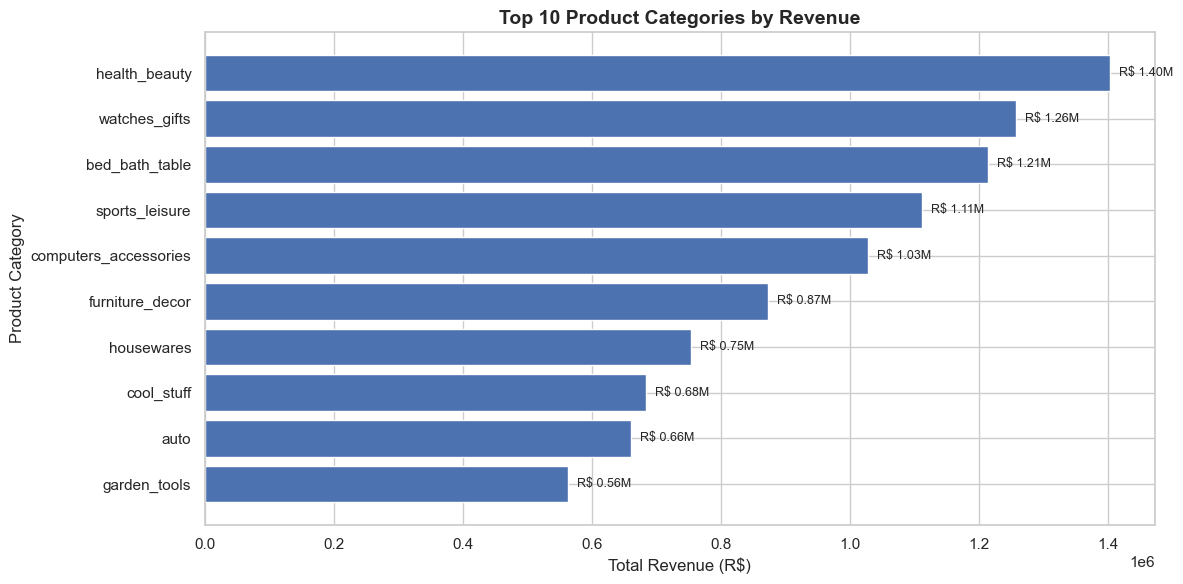

In [14]:
def add_bar_labels(ax, values, money=False):
    max_value = max(values) if len(values) else 0
    for i, value in enumerate(values):
        label = f"R$ {value/1_000_000:.2f}M" if money else f"{value:,.0f}"
        ax.text(value + max_value * 0.01, i, label, va="center", fontsize=9)

plt.figure(figsize=(12, 6))
top_category_revenue = category_performance_df.head(10).sort_values("total_revenue", ascending=True)
ax = plt.barh(top_category_revenue["product_category_name_english"], top_category_revenue["total_revenue"])
plt.title("Top 10 Product Categories by Revenue", fontsize=14, weight="bold")
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Product Category")
add_bar_labels(plt.gca(), top_category_revenue["total_revenue"].values, money=True)
plt.tight_layout()
plt.show()

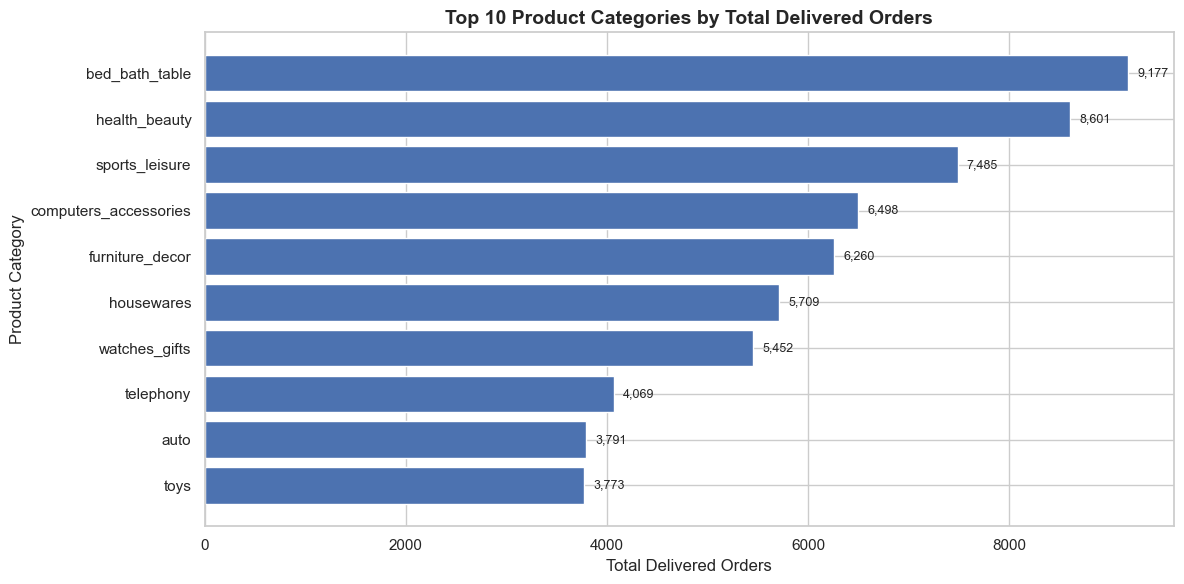

In [15]:
plt.figure(figsize=(12, 6))
top_category_orders = category_performance_df.sort_values("total_orders", ascending=False).head(10).sort_values("total_orders", ascending=True)
plt.barh(top_category_orders["product_category_name_english"], top_category_orders["total_orders"])
plt.title("Top 10 Product Categories by Total Delivered Orders", fontsize=14, weight="bold")
plt.xlabel("Total Delivered Orders")
plt.ylabel("Product Category")
add_bar_labels(plt.gca(), top_category_orders["total_orders"].values, money=False)
plt.tight_layout()
plt.show()

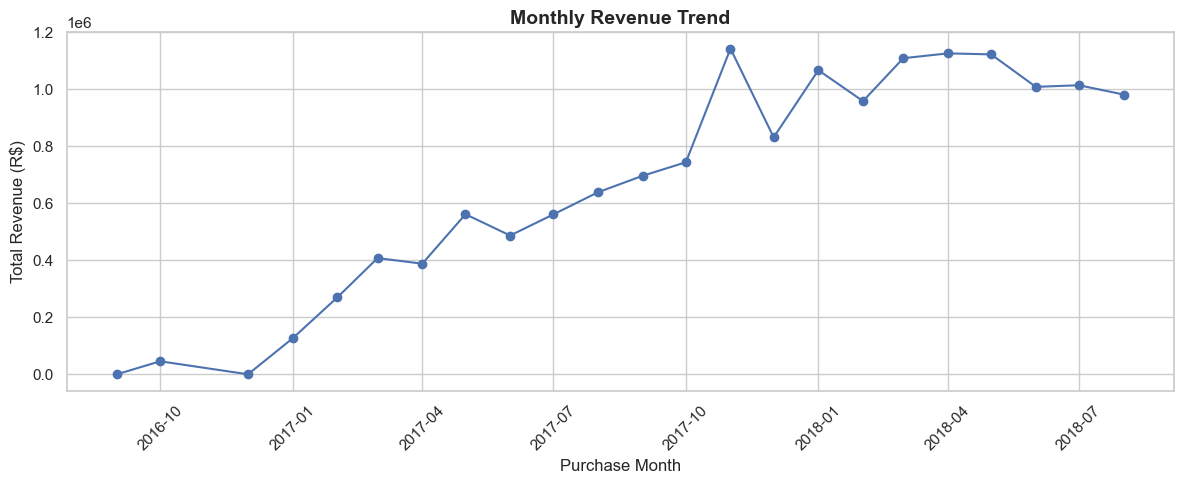

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue_df["purchase_month"], monthly_revenue_df["total_revenue"], marker="o")
plt.title("Monthly Revenue Trend", fontsize=14, weight="bold")
plt.xlabel("Purchase Month")
plt.ylabel("Total Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight Pertanyaan 1:**

- Berdasarkan total revenue, kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** menjadi tiga kategori teratas.
- Jika dilihat dari jumlah pesanan, kategori dengan demand besar juga mencakup **bed_bath_table**, **health_beauty**, dan beberapa kategori kebutuhan rumah atau gaya hidup.
- Kategori dengan revenue tinggi dan volume order tinggi dapat menjadi prioritas untuk promosi, bundling, dan pengelolaan stok.

### Pertanyaan 2: Bagaimana perbedaan skor ulasan pelanggan berdasarkan durasi dan keterlambatan pengiriman?

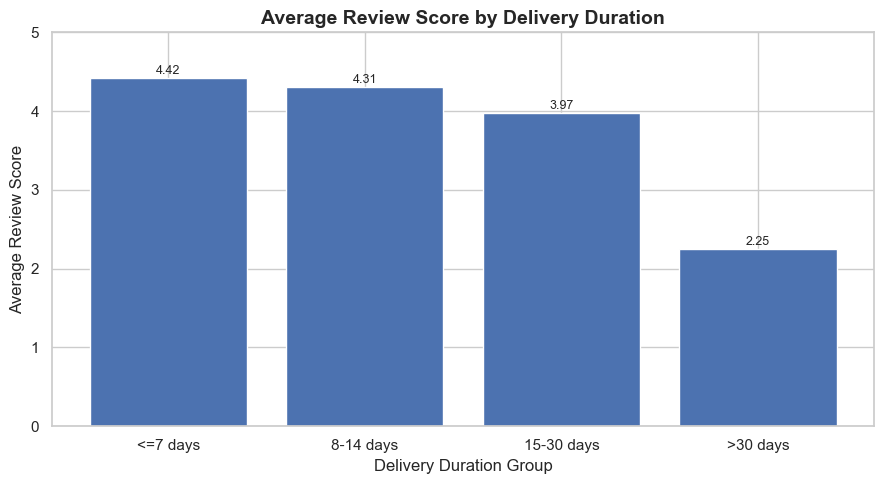

In [17]:
plt.figure(figsize=(9, 5))
plt.bar(delivery_review_df["delivery_group"].astype(str), delivery_review_df["avg_review"])
plt.title("Average Review Score by Delivery Duration", fontsize=14, weight="bold")
plt.xlabel("Delivery Duration Group")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
for i, value in enumerate(delivery_review_df["avg_review"]):
    plt.text(i, value + 0.05, f"{value:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

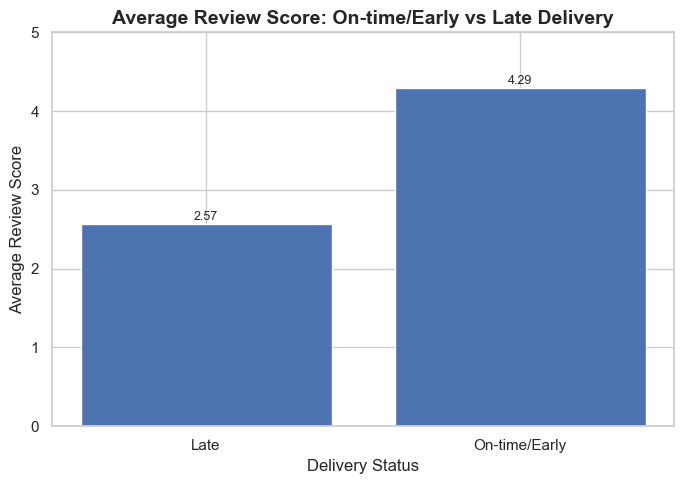

In [18]:
late_plot_df = late_review_df.sort_values("avg_review", ascending=True)
plt.figure(figsize=(7, 5))
plt.bar(late_plot_df["is_late"].astype(str), late_plot_df["avg_review"])
plt.title("Average Review Score: On-time/Early vs Late Delivery", fontsize=14, weight="bold")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
for i, value in enumerate(late_plot_df["avg_review"]):
    plt.text(i, value + 0.05, f"{value:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

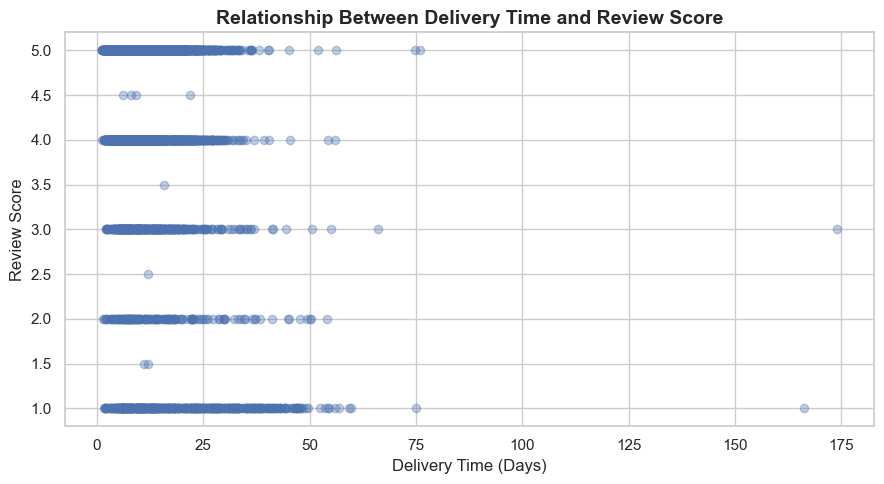

In [19]:
sample_df = order_level_df.sample(min(5000, len(order_level_df)), random_state=42)
plt.figure(figsize=(9, 5))
plt.scatter(sample_df["delivery_time_days"], sample_df["review_score"], alpha=0.35)
plt.title("Relationship Between Delivery Time and Review Score", fontsize=14, weight="bold")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

**Insight Pertanyaan 2:**

- Pesanan yang tiba lebih cepat memiliki rata-rata review score lebih tinggi.
- Pesanan yang terlambat dari estimasi memiliki rata-rata review score jauh lebih rendah dibandingkan pesanan yang on-time atau lebih cepat.
- Perbaikan logistik sebaiknya difokuskan pada pengurangan keterlambatan pengiriman dan monitoring order dengan estimasi pengiriman panjang.

## Analisis Lanjutan: RFM Analysis

**RFM Analysis** digunakan untuk mengelompokkan pelanggan berdasarkan:

- **Recency:** jumlah hari sejak transaksi terakhir pelanggan.
- **Frequency:** jumlah transaksi yang dilakukan pelanggan.
- **Monetary:** total nilai transaksi pelanggan.

Analisis ini tidak menggunakan algoritma machine learning. Segmentasi dilakukan dengan scoring kuartil dan aturan bisnis sederhana.

In [20]:
snapshot_date = analysis_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = (
    analysis_df.groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("revenue", "sum")
    )
    .reset_index()
)

rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase"]).dt.days
rfm_df = rfm_df.drop(columns="last_purchase")

# Scoring kuartil. Recency lebih kecil berarti lebih baik, sehingga skornya dibalik.
rfm_df["r_score"] = pd.qcut(rfm_df["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df["f_score"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["m_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["rfm_score"] = rfm_df[["r_score", "f_score", "m_score"]].sum(axis=1)

def assign_segment(row):
    if row["r_score"] >= 3 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "Champions"
    elif row["r_score"] >= 3 and row["f_score"] >= 2:
        return "Loyal Customers"
    elif row["r_score"] >= 3 and row["f_score"] <= 2:
        return "Potential Loyalists"
    elif row["r_score"] <= 2 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "At Risk"
    else:
        return "Need Attention"

rfm_df["segment"] = rfm_df.apply(assign_segment, axis=1)

rfm_df.head()

,customer_unique_id,frequency,monetary,recency,r_score,f_score,m_score,rfm_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,112,4,1,3,8,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,115,3,1,1,5,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,1,86.22,537,1,1,2,4,Need Attention
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,321,2,1,1,4,Need Attention
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,288,2,1,4,7,Need Attention


In [21]:
rfm_summary_df = (
    rfm_df.groupby("segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

rfm_summary_df

,segment,customers,avg_recency,avg_frequency,avg_monetary
0,Need Attention,34819,364.22,1.00,128.36
1,Loyal Customers,22616,110.85,1.01,113.03
2,Champions,12146,111.99,1.13,272.02
3,Potential Loyalists,11612,112.69,1.00,160.33
4,At Risk,11554,363.33,1.10,268.17


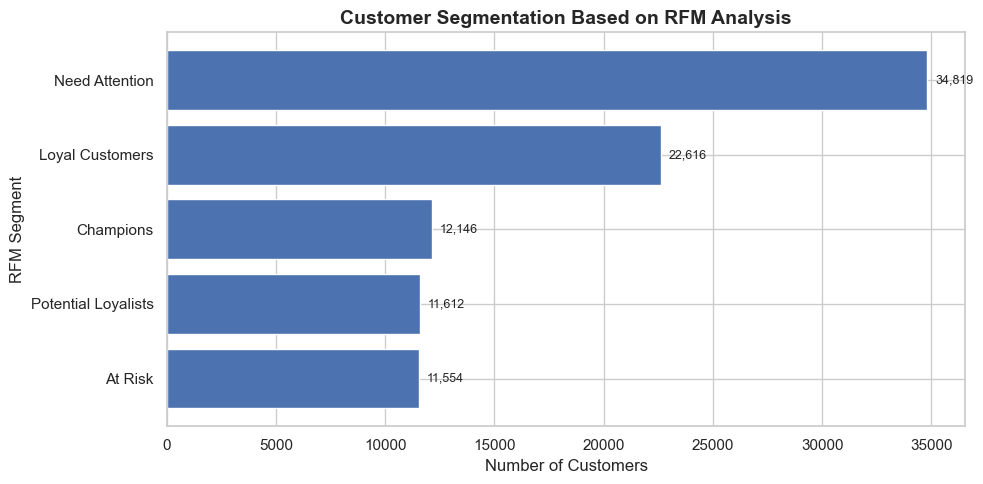

In [22]:
plt.figure(figsize=(10, 5))
rfm_plot_df = rfm_summary_df.sort_values("customers", ascending=True)
plt.barh(rfm_plot_df["segment"], rfm_plot_df["customers"])
plt.title("Customer Segmentation Based on RFM Analysis", fontsize=14, weight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")
add_bar_labels(plt.gca(), rfm_plot_df["customers"].values, money=False)
plt.tight_layout()
plt.show()

**Insight RFM:**

- Segmen **Champions** merupakan pelanggan bernilai tinggi karena memiliki kombinasi recency, frequency, dan monetary yang baik.
- Segmen **At Risk** memiliki monetary dan frequency relatif baik, tetapi recency rendah sehingga perlu strategi reaktivasi.
- Segmen **Need Attention** berjumlah besar sehingga cocok diberi campaign ringan seperti voucher terbatas, rekomendasi produk, atau reminder pembelian ulang.

## Menyiapkan Dataset untuk Dashboard

Dataset yang sudah dibersihkan disimpan ke folder `dashboard/` agar dapat digunakan oleh aplikasi Streamlit.

In [23]:
DASHBOARD_DIR = Path("dashboard")
DASHBOARD_DIR.mkdir(exist_ok=True)

dashboard_columns = [
    "order_id",
    "customer_unique_id",
    "order_item_id",
    "product_id",
    "product_category_name_english",
    "customer_city",
    "customer_state",
    "order_purchase_timestamp",
    "purchase_month",
    "price",
    "freight_value",
    "revenue",
    "payment_value",
    "payment_type",
    "review_score",
    "delivery_time_days",
    "estimated_delivery_days",
    "delay_days",
    "is_late",
    "delivery_group"
]

analysis_df[dashboard_columns].to_csv(DASHBOARD_DIR / "main_data.csv", index=False)
rfm_df.to_csv(DASHBOARD_DIR / "rfm_data.csv", index=False)

print("Dashboard data saved successfully.")
print(f"main_data.csv rows: {len(analysis_df):,}")
print(f"rfm_data.csv rows: {len(rfm_df):,}")

Dashboard data saved successfully.
main_data.csv rows: 109,362
rfm_data.csv rows: 92,747


## Conclusion & Recommendation

### Pertanyaan 1

Kategori dengan revenue tertinggi adalah **health_beauty**, disusul oleh **watches_gifts** dan **bed_bath_table**. Kategori tersebut penting diprioritaskan karena memberikan kontribusi nilai transaksi besar. Dari sisi jumlah pesanan, kategori seperti **bed_bath_table** dan **health_beauty** menunjukkan demand yang tinggi.

**Rekomendasi:**

- Prioritaskan stok dan promosi untuk kategori dengan revenue dan volume order tinggi.
- Lakukan bundling atau campaign musiman untuk kategori top revenue.
- Pantau kategori dengan volume tinggi tetapi review relatif lebih rendah karena dapat menandakan masalah kualitas produk atau layanan.

### Pertanyaan 2

Skor review pelanggan semakin rendah ketika durasi pengiriman semakin lama. Pesanan yang terlambat dari estimasi juga memiliki rata-rata review score lebih rendah dibandingkan pesanan yang tiba tepat waktu atau lebih awal.

**Rekomendasi:**

- Fokus mengurangi keterlambatan pengiriman karena berdampak langsung pada kepuasan pelanggan.
- Buat monitoring khusus untuk order dengan estimasi pengiriman panjang atau risiko delay tinggi.
- Evaluasi performa seller dan area pengiriman yang sering terlambat untuk memperbaiki pengalaman pelanggan.

### RFM Analysis

Segmentasi RFM membantu bisnis menentukan prioritas **customer relationship management**. Segmen **Champions** dapat dipertahankan dengan loyalty program, sedangkan segmen **At Risk** dan **Need Attention** memerlukan campaign reaktivasi.